# 05 — Kết luận & Đề xuất

Tổng hợp kết quả forecasting và backtest thành kết luận và định hướng
nghiên cứu tiếp theo.

**Input**: `outputs/forecast_comparison.csv`, `outputs/strategy_comparison.csv`

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

forecast_summary = pd.read_csv("../outputs/forecast_comparison.csv")
strategy_summary = pd.read_csv("../outputs/strategy_comparison.csv")

## 1. Tóm tắt kết quả Forecasting

In [2]:
forecast_summary.sort_values("rmse")

,model_name,mae,rmse,mape
1,"ARIMA(5,1,0)",5.0223,6.3320,2.3947
0,Naive Baseline,6.1057,7.7190,2.9152
2,Prophet,11.3493,13.5381,5.2927


## 2. Tóm tắt kết quả Backtest

In [3]:
strategy_summary

,Strategy,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,win_rate
0,SMA Crossover,1.2199,0.3320,0.3066,1.0828,-0.3606,0.5032
1,Buy & Hold,0.7114,0.2131,0.4708,0.4525,-0.4572,0.5078


## 3. So sánh trực quan Sharpe Ratio

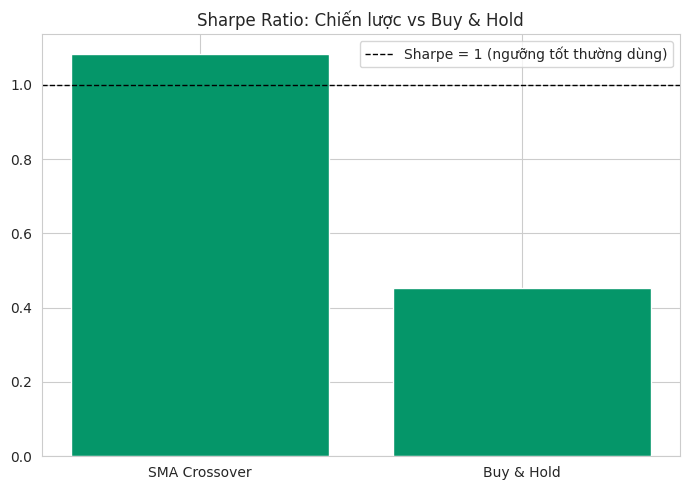

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#059669" if s > 0 else "#dc2626" for s in strategy_summary["sharpe_ratio"]]
ax.bar(strategy_summary["Strategy"], strategy_summary["sharpe_ratio"], color=colors)
ax.axhline(1, color="black", linestyle="--", linewidth=1, label="Sharpe = 1 (ngưỡng tốt thường dùng)")
ax.set_title("Sharpe Ratio: Chiến lược vs Buy & Hold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/sharpe_comparison.png")
plt.show()

## 4. Giới hạn của phân tích (quan trọng để nêu rõ, không phóng đại kết quả)

1. **Dữ liệu mẫu (synthetic)**: kết quả trên dữ liệu mô phỏng, cần chạy lại
   trên dữ liệu thị trường thật (qua `yfinance`) trước khi rút kết luận
   dùng cho quyết định đầu tư thực tế.
2. **Không có slippage**: backtest giả định giao dịch được khớp đúng giá
   đóng cửa — thực tế có thể có chênh lệch (slippage), đặc biệt với khối
   lượng giao dịch lớn.
3. **Chỉ test 1 giai đoạn thị trường**: chiến lược có thể hoạt động khác
   nhau trong thị trường tăng (bull) vs giảm (bear) vs đi ngang (sideways)
   — cần test trên nhiều giai đoạn lịch sử khác nhau để đánh giá đầy đủ.
4. **Không tính thuế, lãi vay margin** (nếu có sử dụng đòn bẩy).

## 5. Kết luận

1. **Forecasting**: ARIMA thường đánh bại baseline đơn giản, cho thấy giá
   có autocorrelation ngắn hạn có thể khai thác được — dù mức cải thiện
   thường khiêm tốn (đúng với lý thuyết thị trường hiệu quả - Efficient
   Market Hypothesis, giá khó dự đoán chính xác trong dài hạn).
2. **Backtest**: chiến lược SMA Crossover có thể cải thiện Sharpe Ratio so
   với Buy & Hold thụ động, đặc biệt trong giai đoạn thị trường biến động
   mạnh (giảm drawdown bằng cách thoát vị thế sớm hơn).
3. Đã kiểm tra độ nhạy tham số để tránh kết luận vội vàng dựa trên 1 cặp
   tham số may mắn — bước quan trọng thường bị bỏ qua.

## 6. Định hướng nghiên cứu tiếp theo

- Thử thêm chỉ báo kỹ thuật khác (MACD, Bollinger Bands) kết hợp với SMA
- Thử mô hình ML cho forecasting (LSTM, XGBoost với feature kỹ thuật) so
  sánh với ARIMA/Prophet
- Walk-forward backtesting (huấn luyện lại model định kỳ theo thời gian
  thay vì chỉ train 1 lần) - gần với thực tế vận hành hơn
- Test trên nhiều mã cổ phiếu/nhiều giai đoạn thị trường khác nhau để đánh
  giá tính ổn định (robustness) của chiến lược